# Template for Spectral and temporal modifications Lab


*From R. Badeau and G. Richard (with help from P. Vernhet), MAJ:2019*

**python version : 3.6**

In [1]:
import os, sys, wave, struct

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import IPython

from copy import deepcopy
from math import ceil
from scipy.io.wavfile import write

from scipy.signal.windows import hann

## Functions

In [2]:
def load_sound(file):
    return wave.open(file, 'rb')
    
def plot_sound(data, times, name='default_name', save=False):
    plt.figure(figsize=(30, 4))
    plt.fill_between(times, data)
    plt.xlim(times[0], times[-1])
    plt.xlabel('time (s)')
    plt.ylabel('amplitude')
    if save:
        plt.savefig(name+'.png', dpi=100)
    plt.show()

def nextpow2(x):
    assert x>0
    p = ceil(np.log2(x))
    x_ = 2**p
    assert 2**(p-1) < x <= x_
    return p, x_

def period(x, Fs, Pmin=1/300, Pmax=1/80, seuil=0.7) :
    # [P,voiced] = period(x,Fs,Pmin,Pmax,seuil);
    # If voiced = 1, P is the period signal x expressed in number of samples
    # If voiced = 0, P is equal to 10ms.Fs

    x = x - np.mean(x)
    N = len(x)

    Nmin = np.ceil(Pmin*Fs).astype(int)
    Nmax = 1 + np.floor(Pmax*Fs).astype(int)
    Nmax = np.min([Nmax,N])

    _,Nfft = nextpow2(2*N-1)
    X = np.fft.fft(x, n=Nfft)
    S = X * np.conj(X) / N
    r = np.real(np.fft.ifft(S))

    rmax = np.max(r[Nmin:Nmax])
    I = np.argmax(r[Nmin:Nmax])
    P = I+Nmin
    corr = (rmax/r[0]) * (N/(N-P))
    voiced = corr > seuil
    if not(voiced):
        P = np.round(10e-3*Fs)

    return P,voiced

## Reading and playing .wav file

Choose the name of sound for the rest of the notebook. Sounds are assumed to be set in a folder named 'sons_mutltipitch' (same directory as notebook).

In [91]:
data_path = os.getcwd()
filename = 'new_aeiou.wav'
sound = os.path.join(data_path, filename) 

### **Using wave**

In [92]:
wavefile = load_sound(sound)
print(wavefile.getparams())

_wave_params(nchannels=1, sampwidth=2, framerate=11025, nframes=59964, comptype='NONE', compname='not compressed')


In [133]:
IPython.display.Audio('aeiou.wav')

In [94]:
Fs = int(wavefile.getframerate())
num_samples = int(wavefile.getnframes())
data = wavefile.readframes(num_samples)
data = struct.unpack('{n}h'.format(n=num_samples), data)
x = np.array(data)

In [95]:
timestep = 1/float(Fs)
times = np.arange(len(x))*timestep

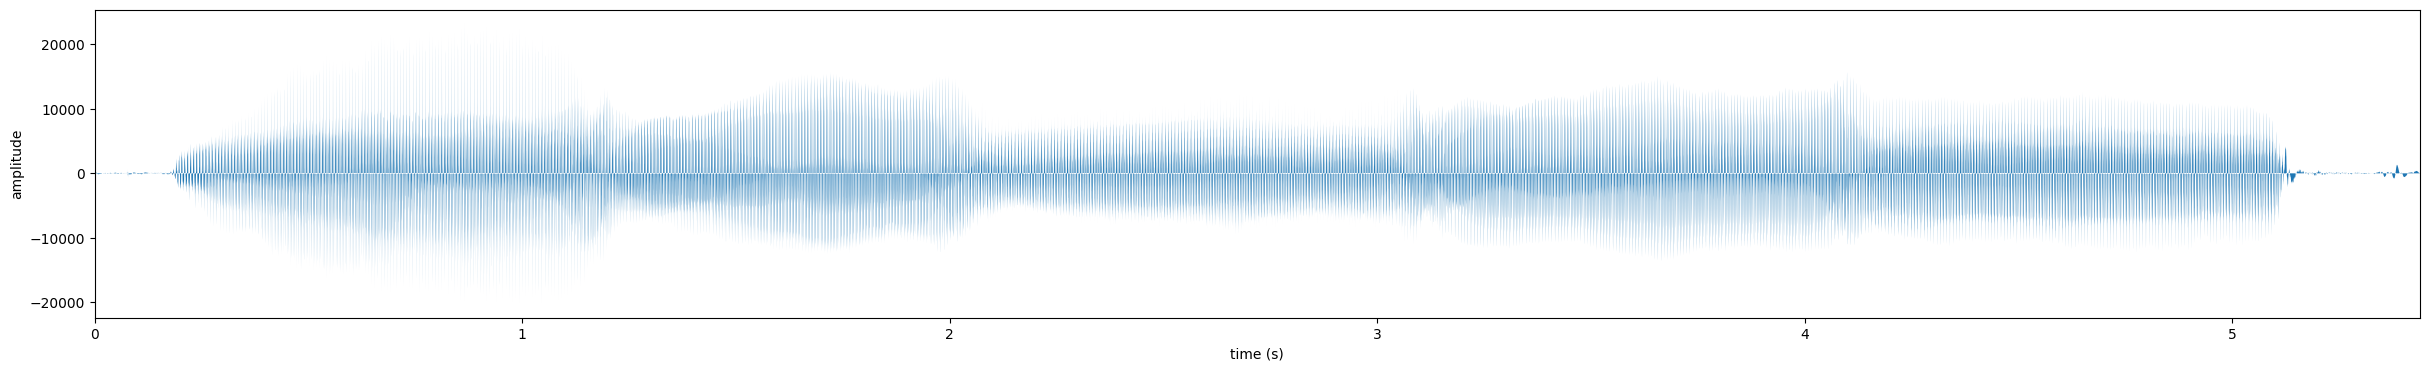

In [96]:
plot_sound(x, times)

In [97]:
write('new_aeiou.wav', Fs, np.array(x, dtype=np.int16)) # to write a new wave file

In [98]:
P,voiced = period(x, Fs)
P, voiced

(np.int64(83), np.True_)

In [99]:
def AnalysisPitchMarks(s, Fs, N):

    A = np.zeros((2, N), dtype=float)

    ta = 0
    Pa = int(round(0.01 * Fs))  # 10 ms

    for n in range(N):
        
        A[0, n] = ta
        A[1, n] = Pa

        start = int(ta)
        end = int(start + 2.5 * Pa)
        if start >= len(s):
            break
        end = min(end, len(s))
        x = s[start:end]

        Pa, _ = period(x, Fs)
        Pa = int(round(Pa))
        ta = ta + Pa

    return A


In [ ]:
A = AnalysisPitchMarks(x, Fs, 700)

In [101]:
test_B = np.zeros_like(A)
test_B[0,:] = A[0,:]
test_B[1,:] = range(0,A.shape[1]) 

In [102]:
print(test_B)
print(test_B.shape)

[[0.000e+00 1.100e+02 2.200e+02 ... 5.881e+04 5.892e+04 5.903e+04]
 [0.000e+00 1.000e+00 2.000e+00 ... 6.970e+02 6.980e+02 6.990e+02]]
(2, 700)


In [103]:
print(A)

[[    0.   110.   220. ... 58810. 58920. 59030.]
 [  110.   110.   110. ...   110.   110.   110.]]


In [104]:
def Synthesis(s, Fs, A, B):
    k_max = B.shape[1] 

    nk_end =  int(B[1, k_max - 1])
    Pa_end = int(A[1, nk_end])
    ts_end = int(B[0, k_max - 1])
    y = np.zeros(ts_end + Pa_end + 1)

    for k in range(k_max):
        
        nk = int(B[1, k])
        ta = int(A[0, nk])
        Pa = int(A[1, nk])

        width = 2 * Pa + 1

        start = ta - Pa
        end = ta + Pa + 1  

        # clip s
        s_start = max(0, start)
        s_end = min(len(s), end)

        x = s[s_start:s_end]

        # Hann
        xw = x * hann(len(x), sym=True)

        ts = int(B[0, k])

        # zone y 
        y_start = ts - Pa
        y_end = ts + Pa + 1

        # clip y + alignement xw
        yy_start = max(0, y_start)
        yy_end = min(len(y), y_end)

        # shift in xw
        xw_start = yy_start - y_start
        xw_end   = min(len(xw), xw_start + xw_start + (yy_end - yy_start))
        
        yy_end = yy_start + (xw_end - xw_start)

        if yy_end > yy_start and xw_end > xw_start:
            y[yy_start:yy_end] += xw[xw_start:xw_end]

    return y


In [105]:
y = Synthesis(x,Fs,A,test_B) # should be a copy of the initial signal with this B
y

array([ 0.        , -0.06891941, -0.27806778, ...,  0.17939857,
        0.04343146,  0.        ], shape=(59141,))

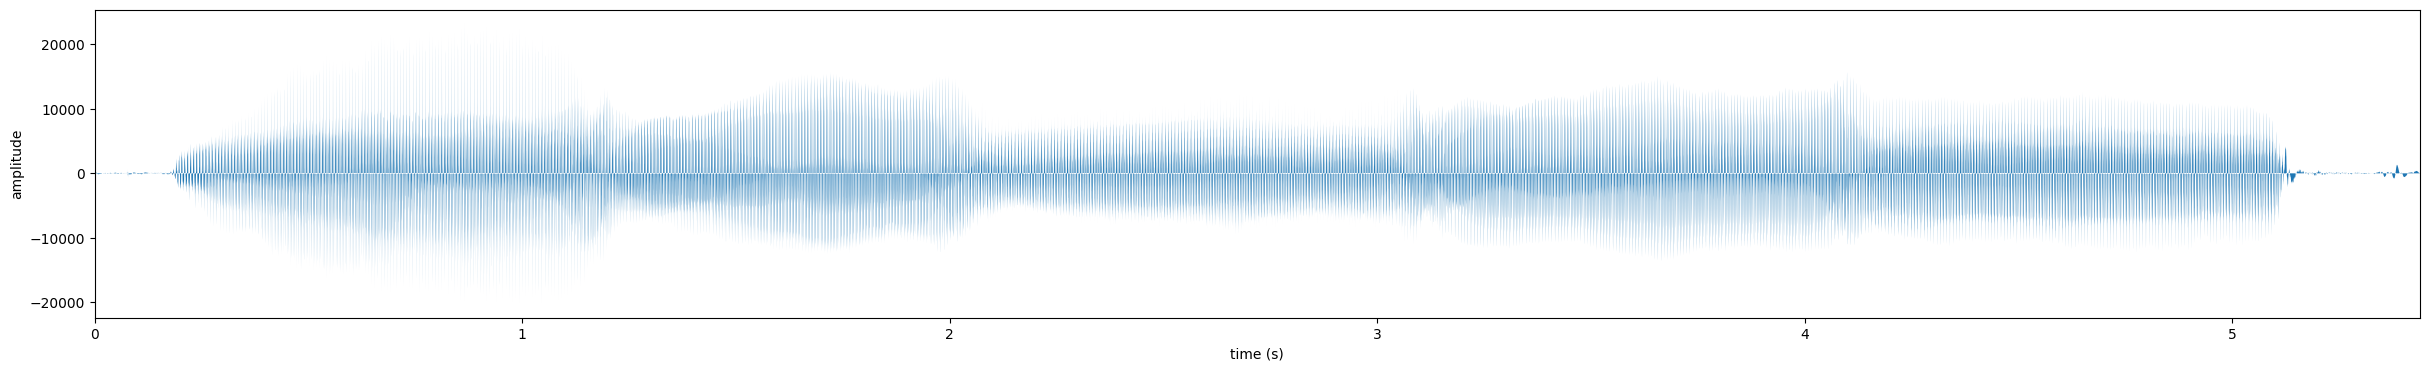

In [106]:
timestep = 1/float(Fs)
times = np.arange(len(x))*timestep
plot_sound(x, times)

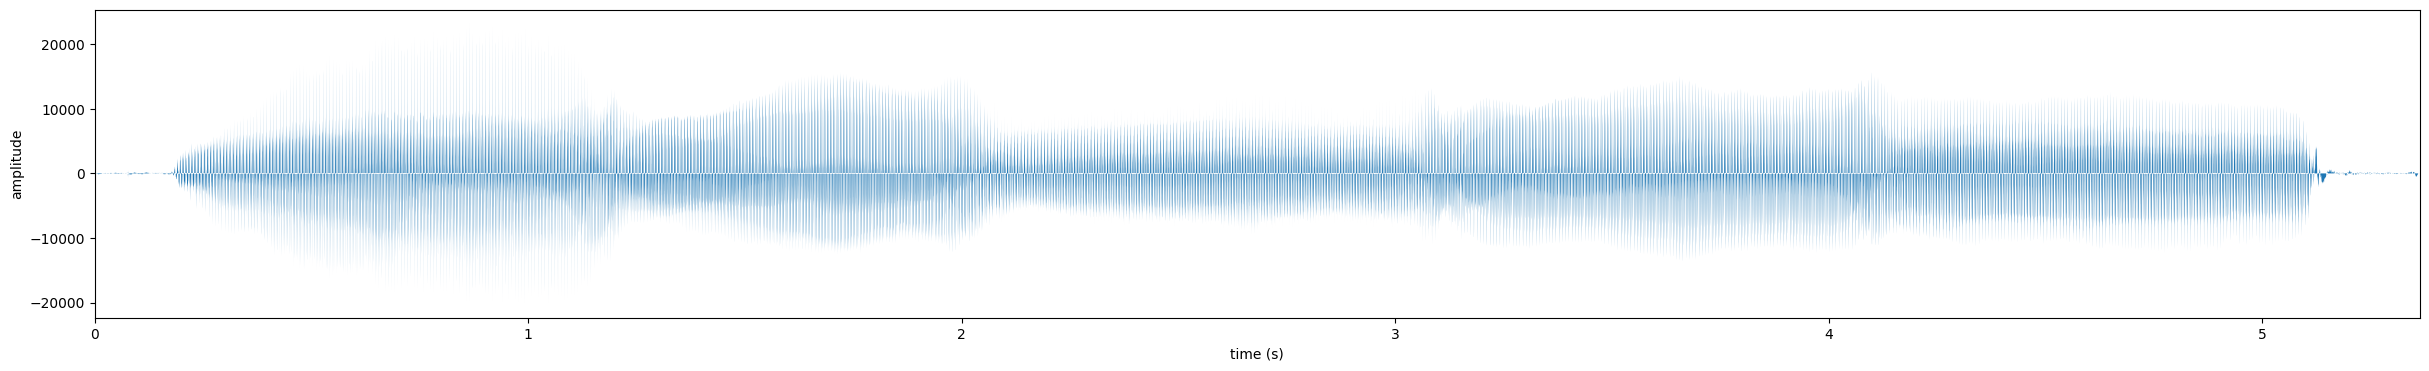

In [107]:
timestep = 1/float(Fs)
times = np.arange(len(y))*timestep
plot_sound(y, times)

In [108]:
from IPython.display import Audio

Audio(y, rate=Fs)


In [120]:
def ChangeTimeScale(alpha,A,Fs):

    ts_list= [1]
    nk_list = [0,1]
    ts = 1
    nk = 1
    N = A.shape[1]
        
    while int(nk)<=N-1:
        
        ts += A[1,int(nk)]
        nk +=  1/alpha
        
        ts_list.append(ts)
        nk_list.append(nk)
        
    
    
    B = np.array([ts_list, nk_list[:len(ts_list)]])
    return B
    

In [134]:
B = ChangeTimeScale(1/3,A,Fs)
B

array([[1.0000e+00, 1.1100e+02, 2.2100e+02, 3.3100e+02, 4.4100e+02,
        5.5100e+02, 6.6100e+02, 7.3000e+02, 8.0600e+02, 8.8200e+02,
        9.6200e+02, 1.0430e+03, 1.1250e+03, 1.2080e+03, 1.2910e+03,
        1.3750e+03, 1.4590e+03, 1.5430e+03, 1.6270e+03, 1.7110e+03,
        1.7950e+03, 1.8790e+03, 1.9630e+03, 2.0470e+03, 2.1310e+03,
        2.2140e+03, 2.2970e+03, 2.3790e+03, 2.4610e+03, 2.5440e+03,
        2.6260e+03, 2.7080e+03, 2.7900e+03, 2.8730e+03, 2.9560e+03,
        3.0390e+03, 3.1220e+03, 3.2050e+03, 3.2880e+03, 3.3710e+03,
        3.4540e+03, 3.5380e+03, 3.6210e+03, 3.7050e+03, 3.7890e+03,
        3.8730e+03, 3.9570e+03, 4.0410e+03, 4.1250e+03, 4.2090e+03,
        4.2930e+03, 4.3760e+03, 4.4590e+03, 4.5410e+03, 4.6230e+03,
        4.7050e+03, 4.7870e+03, 4.8690e+03, 4.9510e+03, 5.0330e+03,
        5.1150e+03, 5.1980e+03, 5.2810e+03, 5.3640e+03, 5.4470e+03,
        5.5300e+03, 5.6130e+03, 5.6960e+03, 5.7790e+03, 5.8620e+03,
        5.9440e+03, 6.0260e+03, 6.1080e+03, 6.19

In [135]:
y = Synthesis(x,Fs,A,B)
y

array([-0.08888384,  0.        , -0.06891941, ...,  0.13699527,
        0.0340519 ,  0.        ], shape=(19732,))

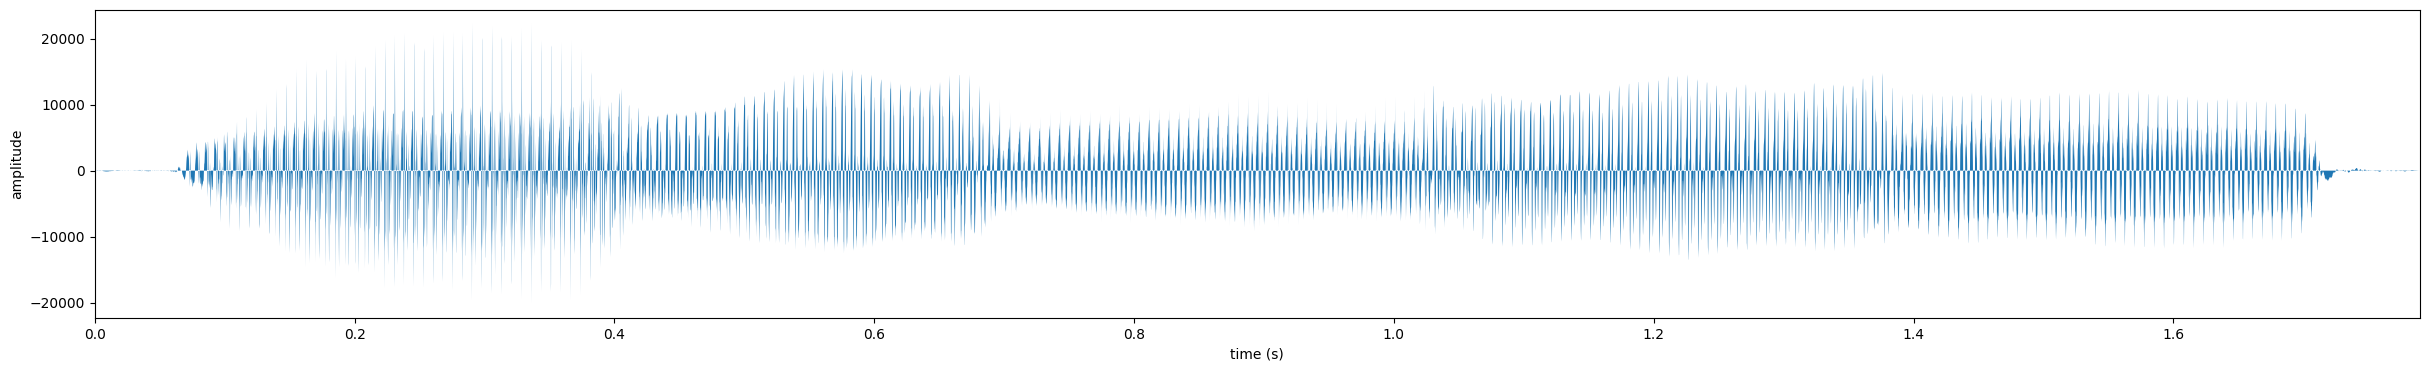

In [136]:
timestep = 1/float(Fs)
times = np.arange(len(y))*timestep
plot_sound(y, times)

In [137]:
Audio(y, rate=Fs)